# 06 — DTW on real machine data

Notebooks 01-05 run on the seeded synthetic dataset, where every variant differs from the
reference by exactly one known distortion.  This notebook applies the same DTW
implementation to two real recordings from `data/mat-files/`, where nothing is controlled:
the two runs have different durations, different numbers of motion cycles, and their own
noise.

**What we compare.** The position `q` of axis 3 in `intimeData_7` and `intimeData_8` — the
rotary axis, and the only one that moves in both files.  Both runs sweep back and forth
between +180° and -180°, but file 7 sweeps 6 times in 647 s while file 8 sweeps 8 times in
520 s.  Two series of a similar shape running at different speeds and different lengths.

In [8]:
import sys
from pathlib import Path

# The notebooks live in `notebooks/`, the packages in the project root.
ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.mat_data import get_state_series
from utils import plotting
from utils.distances import dtw_cost_matrix, dtw_path

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

## Loading the recordings

The recordings are sampled at 1 kHz, which the from-scratch DP implementation cannot take
raw: its cost matrix is `O(n*m)`, so the full 647380 x 517375 pair would need roughly
2.7 PB.  `step=500` decimates to 2 Hz — 1295 x 1035 cells, about 2 s to fill — and one
sweep lasts ~100 s, so nothing of the shape is lost. 

In [9]:
STEP = 500  # 1 kHz -> 2 Hz; cost matrix grows as (N/STEP)^2

data = get_state_series(
    files=("intimeData_7", "intimeData_8"),
    channels=("q",),
    axis=3,
    group="trajectory",   # axis 3 has no state.q — see the note above
    step=STEP,
)

a, b = data["intimeData_7"], data["intimeData_8"]

print(f"{'file':>15}  {'samples':>7}  {'duration':>9}  {'q range':>22}")
for name, rec in data.items():
    print(f"{name:>15}  {len(rec['t']):>7}  {rec['t'][-1]:>8.1f} s  "
          f"{rec['q'].min():>9.1f} .. {rec['q'].max():>6.1f} deg")

           file  samples   duration                 q range
   intimeData_7     1295     647.2 s     -180.0 ..  180.0 deg
   intimeData_8     1035     520.2 s     -180.0 ..  180.0 deg


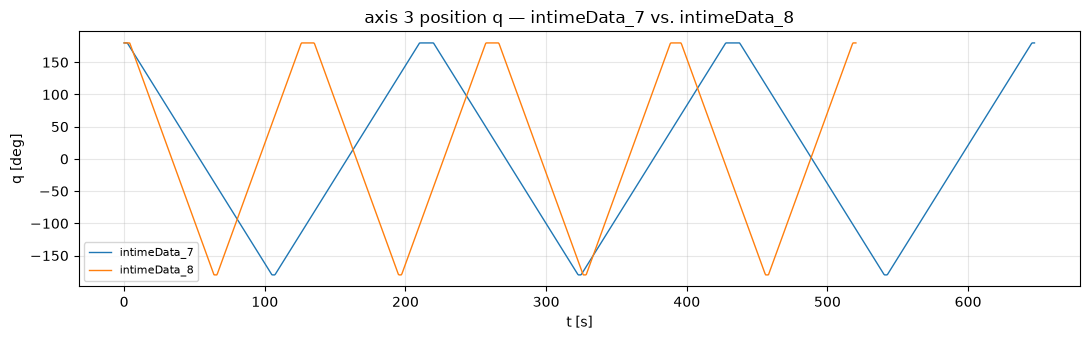

In [10]:
# The two recordings on a real time axis: same motion, different pace and length.
plt.figure(figsize=(11, 3.5))
for name, rec in data.items():
    plt.plot(rec["t"], rec["q"], lw=1.0, label=name)
plt.title("axis 3 position q — intimeData_7 vs. intimeData_8")
plt.xlabel("t [s]")
plt.ylabel("q [deg]")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## DTW

In [11]:
D_q = dtw_cost_matrix(a["q"], b["q"])
path_q = dtw_path(D_q)

print(f"cost matrix   : {D_q.shape}")
print(f"dtw distance  : {D_q[-1, -1]:,.1f} deg (summed over the path)")
print(f"path length   : {len(path_q)} pairs")
print(f"normalised    : {D_q[-1, -1] / len(path_q):,.3f} deg per aligned pair")

cost matrix   : (1296, 1036)
dtw distance  : 25,823.8 deg (summed over the path)
path length   : 1555 pairs
normalised    : 16.607 deg per aligned pair


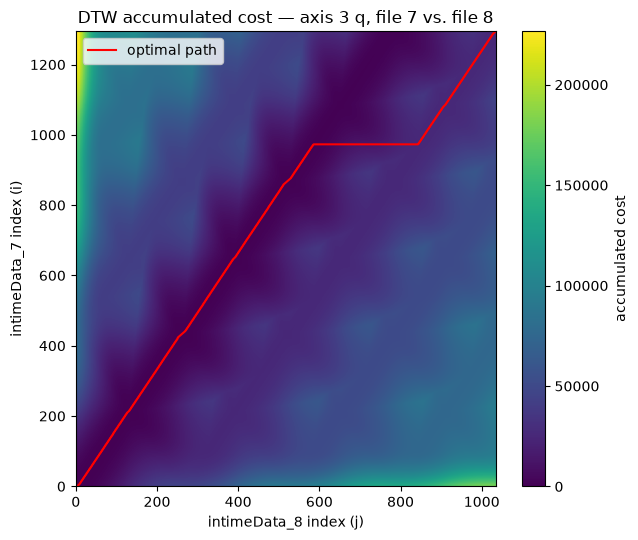

In [12]:
plotting.plot_cost_matrix(
    D_q[1:, 1:],  # drop the padding border for plotting
    path=path_q,
    title="DTW accumulated cost — axis 3 q, file 7 vs. file 8",
    xlabel="intimeData_8 index (j)",
    ylabel="intimeData_7 index (i)",
)

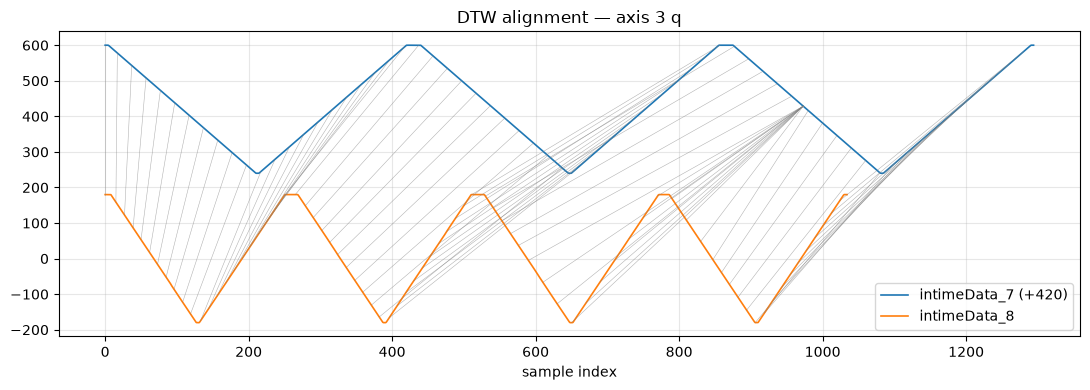

In [13]:
# The alignment on the signals themselves. The staircase in the path above shows up here
# as fans of grey lines: where one recording dwells at +180 deg, DTW matches many of its
# samples to a single sample of the other.
plotting.plot_alignment(
    a["q"], b["q"], path_q,
    labels=("intimeData_7", "intimeData_8"),
    offset=420.0, every=20,
    title="DTW alignment — axis 3 q",
)

## Distances

In [14]:
control = get_state_series(files=("intimeData_8",), channels=("q",), axis=4,
                           group="trajectory", step=STEP)["intimeData_8"]["q"]


def resample_to(x: np.ndarray, n: int) -> np.ndarray:
    """Linearly resample ``x`` to ``n`` samples (needed for the Euclidean baseline)."""
    return np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(x)), x)


def compare(x: np.ndarray, y: np.ndarray) -> dict:
    """DTW (raw and path-normalised) plus the Euclidean baseline for one pair."""
    D = dtw_cost_matrix(x, y)
    path = dtw_path(D)
    return {
        "dtw": float(D[-1, -1]),
        "path_len": len(path),
        "dtw_norm": float(D[-1, -1]) / len(path),
    }


pairs = {
    "q: 7 vs 8": (a["q"], b["q"]),
}

table = pd.DataFrame({name: compare(x, y) for name, (x, y) in pairs.items()}).T
table

,dtw,path_len,dtw_norm
q: 7 vs 8,"25,823.824","1,555.000",16.607
